In [2]:
# -*- coding: utf-8 -*-
"""BuildingCreditCardFraudDetectionModelwithRandomForest.ipynb

Automatically generated by Colaboratory.

Original file is located at
    https://colab.research.google.com/drive/18UIiiPyIL6Pd-RRzl9w0J7HXSY_u5IE-
"""

import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# from google.colab import files    # these two lines to run in colab
# uploaded = files.upload()


In [3]:

data = pd.read_csv("card_transdata.csv")

data.head()

X = data.drop("fraud",axis=1)
y = data["fraud"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train,y_train)
new_transaction_features = data.sample(1).drop('fraud',axis=1)
print("\nRandomly sampled features for new transaction:")
print(new_transaction_features)
prediction = rf_classifier.predict(new_transaction_features)
print("\nPrediction for new transaction:")
print("Fraud" if prediction[0] == 1 else "Legitimate")

new_transaction_features1 = pd.DataFrame({
    'distance_from_home': [7],
    'distance_from_last_transaction': [3],
    'ratio_to_median_purchase_price': [0.1],
    'repeat_retailer': [0],
    'used_chip': [1],
    'used_pin_number': [0],
    'online_order': [0]
})
prediction = rf_classifier.predict(new_transaction_features1)
print("\nPrediction for new transaction:")
print("Fraud" if prediction[0] == 1 else "Legitimate")


Randomly sampled features for new transaction:
       distance_from_home  distance_from_last_transaction  \
16493           20.968074                          2.7098   

       ratio_to_median_purchase_price  repeat_retailer  used_chip  \
16493                        0.361842              1.0        0.0   

       used_pin_number  online_order  
16493              0.0           0.0  

Prediction for new transaction:
Legitimate

Prediction for new transaction:
Legitimate


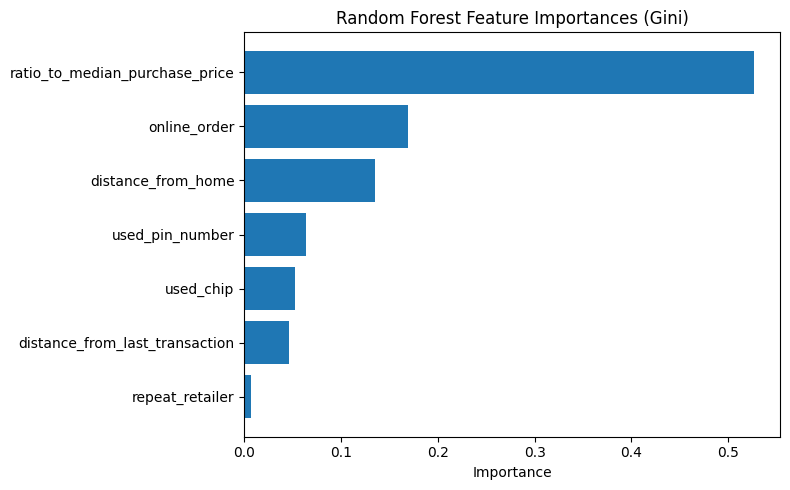

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Get importances
importances = rf_classifier.feature_importances_
feat_names = X_train.columns

# Sort descending
idx = np.argsort(importances)[::-1]
sorted_feats = feat_names[idx]
sorted_imps = importances[idx]

# Plot
plt.figure(figsize=(8,5))
plt.barh(sorted_feats, sorted_imps)
plt.gca().invert_yaxis()  # most important on top
plt.title("Random Forest Feature Importances (Gini)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


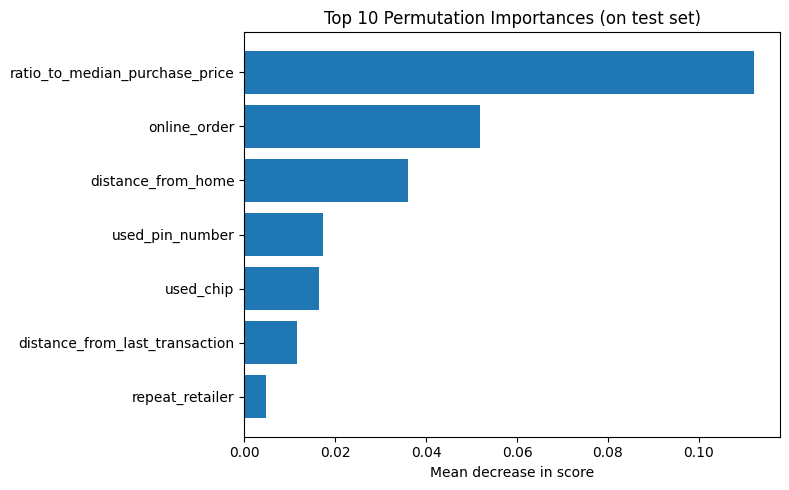

In [5]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf_classifier, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_imps = result.importances_mean
perm_idx = np.argsort(perm_imps)[::-1]

plt.figure(figsize=(8,5))
plt.barh(X_test.columns[perm_idx][:10], perm_imps[perm_idx][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Permutation Importances (on test set)")
plt.xlabel("Mean decrease in score")
plt.tight_layout()
plt.show()


In [7]:
# -*- coding: utf-8 -*-
"""BuildingCreditCardFraudDetectionModelwithLogisticRegression.ipynb

Automatically generated by Colaboratory.

Original file is located at
    https://colab.research.google.com/drive/10-4Dm_XmS2Cve-dKQ-1MplKvWcRRQE09
"""

import pandas as pd
# from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# uploaded = files.upload()

# data = pd.read_csv("card_transdata.csv")

# data.head()

# X = data.drop("fraud",axis=1)
# y = data["fraud"]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
logreg_classifier = LogisticRegression(max_iter=1000, random_state=42)
logreg_classifier.fit(X_train_scaled,y_train)
new_transaction_features1 = pd.DataFrame({
    'distance_from_home': [89],
    'distance_from_last_transaction': [15],
    'ratio_to_median_purchase_price': [2.3],
    'repeat_retailer': [1],
    'used_chip': [0],
    'used_pin_number': [1],
    'online_order': [1]
})
prediction = logreg_classifier.predict(scaler.transform(new_transaction_features1))
print("\nPrediction for New Transaction:")
print("Fraud" if prediction[0] == 1 else "Legitimate")


Prediction for New Transaction:
Legitimate


In [10]:
# -*- coding: utf-8 -*-
"""BuildingCreditCardFraudDetectionModelwithSVM.ipynb

Automatically generated by Colaboratory.

Original file is located at
    https://colab.research.google.com/drive/1BistWkfDgI0sqRp236WbIblU-Svp3ZEU
"""

import pandas as pd
# from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

# uploaded = files.upload()

data = pd.read_csv("card_transdata.csv").sample(1000,random_state=42)

data.head()

X = data.drop("fraud",axis=1)
y = data["fraud"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
svm_classifier = SVC(kernel = "linear", probability=True, random_state=42)
calibrated_svm = CalibratedClassifierCV(svm_classifier)
calibrated_svm.fit(X_scaled,y)
distance_from_home = float(input("Enter Distance From Home: "))
distance_from_last_transaction = float(input("Enter Distance From Last Transaction: "))
ratio_to_median_purchase_price = float(input("Enter Ratio to Median Purchase Price: "))
repeat_retailer = int(input("Enter Repeat Retailer (0 or 1): "))
used_chip = int(input("Enter Used Chip (0 or 1): "))
used_pin_number = int(input("Enter Used Pin Number (0 or 1): "))
online_order = int(input("Enter Online Order (0 or 1): "))
new_transaction_features = pd.DataFrame({
    'distance_from_home': [distance_from_home],
    'distance_from_last_transaction': [distance_from_last_transaction],
    'ratio_to_median_purchase_price': [ratio_to_median_purchase_price],
    'repeat_retailer': [repeat_retailer],
    'used_chip': [used_chip],
    'used_pin_number': [used_pin_number],
    'online_order': [online_order]
})
scaled_transaction = scaler.transform(new_transaction_features)
prediction = calibrated_svm.predict(scaled_transaction)
probability_of_fraud = calibrated_svm.predict_proba(scaled_transaction)[:,1][0]
print("\nPrediction for New Transaction:")
print("Fraud" if prediction[0] == 1 else "Legitimate")
print(f"Probability of Fraud: {probability_of_fraud * 100:.2f}%")


Prediction for New Transaction:
Legitimate
Probability of Fraud: 0.09%


In [11]:
# -*- coding: utf-8 -*-
"""EvaluatingModelPerformancewithPrecisionRecall&F1Score.ipynb

Automatically generated by Colaboratory.

Original file is located at
    https://colab.research.google.com/drive/10-4Dm_XmS2Cve-dKQ-1MplKvWcRRQE09
"""

import pandas as pd
# from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score

# uploaded = files.upload()

data = pd.read_csv("card_transdata.csv")

data.head()

X = data.drop("fraud",axis=1)
y = data["fraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
logreg_classifier = LogisticRegression(max_iter=1000, random_state=42)
logreg_classifier.fit(X_train_scaled,y_train)
new_transaction_features1 = pd.DataFrame({
    'distance_from_home': [89],
    'distance_from_last_transaction': [15],
    'ratio_to_median_purchase_price': [2.3],
    'repeat_retailer': [1],
    'used_chip': [0],
    'used_pin_number': [1],
    'online_order': [1]
})
prediction = logreg_classifier.predict(scaler.transform(new_transaction_features1))
print("\nPrediction for New Transaction:")
print("Fraud" if prediction[0] == 1 else "Legitimate")

y_pred = logreg_classifier.predict(X_test_scaled)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
accuracy = accuracy_score(y_test,y_pred)
print("\nEvaluation Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"f1 score: {f1:.4f}")
print(f"accuracy: {accuracy:.4f}")


Prediction for New Transaction:
Legitimate

Evaluation Metrics:
Precision: 0.8902
Recall: 0.5974
f1 score: 0.7150
accuracy: 0.9585


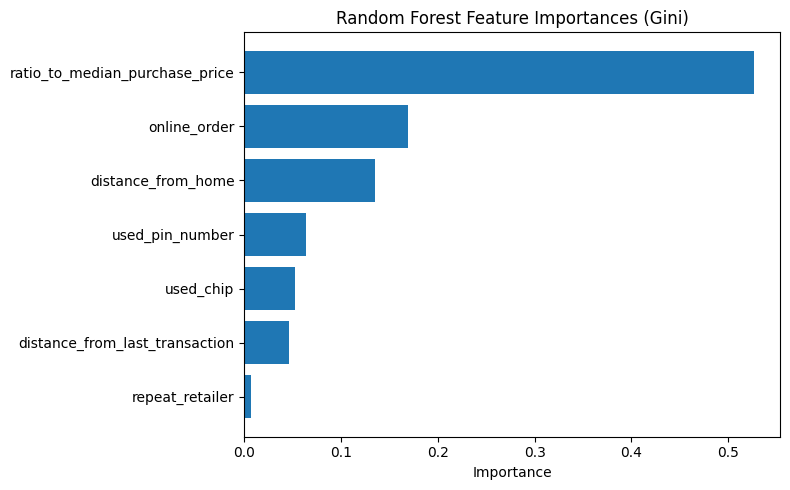

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Get importances
importances = rf_classifier.feature_importances_
feat_names = X_train.columns

# Sort descending
idx = np.argsort(importances)[::-1]
sorted_feats = feat_names[idx]
sorted_imps = importances[idx]

# Plot
plt.figure(figsize=(8,5))
plt.barh(sorted_feats, sorted_imps)
plt.gca().invert_yaxis()  # most important on top
plt.title("Random Forest Feature Importances (Gini)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
